# Intelligent Resume Screening System #
#### Recruiters often receive hundreds or thousands of resumes for a single job opening. Manually reviewing every resume is time-consuming and inconsistent. ####

### Section 1: Install Required Libraries ###

In [2]:
pip install numpy pandas matplotlib seaborn scikit-learn nltk spacy pdfplumber python-docx PyPDF2 wordcloud tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to C:\Users\Trupthi Nazre
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Trupthi Nazre
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Trupthi Nazre
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\Trupthi Nazre
[nltk_data]     K\AppData\Roaming\nltk_data...


True

In [2]:
!pip install spacy
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12

In [5]:
import os
import re
import string

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import nltk
import spacy

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pdfplumber
from docx import Document

from wordcloud import WordCloud

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [4]:
import spacy

nlp = spacy.load("en_core_web_sm")
print("spaCy model loaded successfully!")

spaCy model loaded successfully!


 ### Section 2: Load Dataset ###

In [8]:
df = pd.read_csv(r"C:\Users\Trupthi Nazre K\OneDrive\Desktop\Trupthi\Projects\Ml Projects\Resume-Screening-System\datasets\resume_dataset.csv")

In [11]:
df.head()

,Resume,Category
0,Python Developer Python Developer Philadelphia...,Python_Developer
1,Python Developer Python Developer Python Devel...,Python_Developer
2,R&D Engineer R&D Engineer R&D Engineer - Nokia...,Python_Developer
3,Sr. Full Stack Developer Sr. Full Stack Develo...,Python_Developer
4,Sr. Full Stack Python Developer Sr. Full Stack...,Python_Developer


In [13]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8234, 2)


In [14]:
print(df.columns)

Index(['Resume', 'Category'], dtype='object')


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8234 entries, 0 to 8233
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Resume    8234 non-null   object
 1   Category  8234 non-null   object
dtypes: object(2)
memory usage: 128.8+ KB


In [16]:
df.isnull().sum()

Resume      0
Category    0
dtype: int64

In [17]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 67


In [18]:
df.describe(include='all')

,Resume,Category
count,8234,8234
unique,8167,10
top,Java Developer Java Developer Java Developer -...,Python_Developer
freq,2,1278


### Section 3: Exploratory Data Analysis ###

In [20]:
df["Category"].value_counts()

Category
Python_Developer          1278
Java_Developer            1242
Web_Developer              984
Database_Administrator     920
Security_Analyst           876
Systems_Administrator      776
Project_manager            722
Front_End_Developer        530
Network_Administrator      469
Software_Developer         437
Name: count, dtype: int64

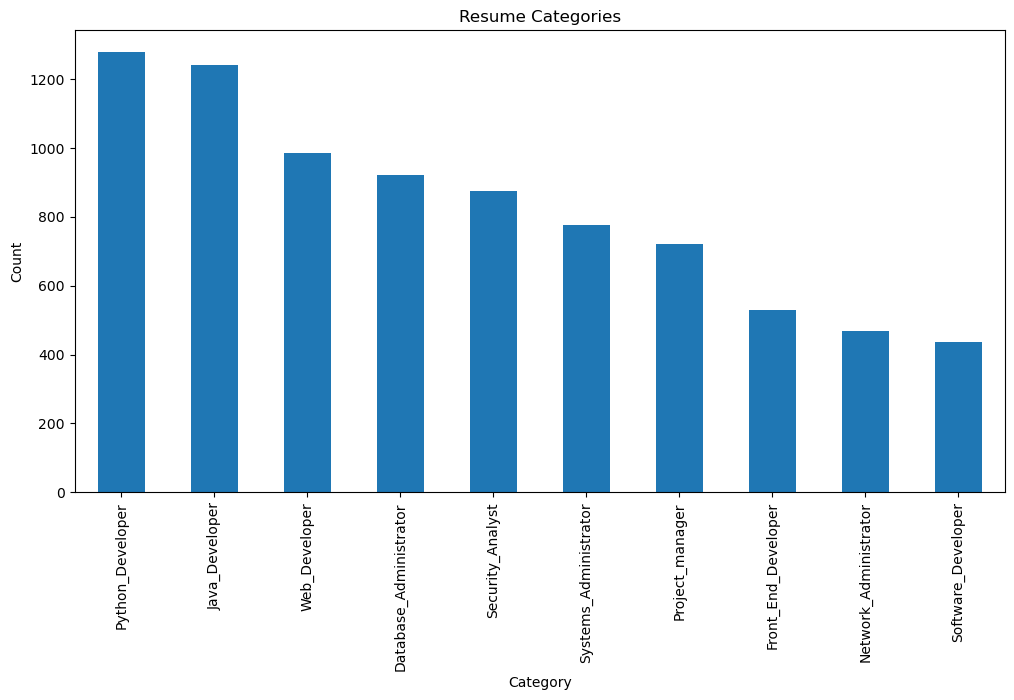

In [21]:
plt.figure(figsize=(12,6))

df["Category"].value_counts().plot(kind="bar")

plt.title("Resume Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

In [23]:
df["Resume_Length"] = df["Resume"].apply(lambda x: len(str(x).split()))
df["Resume_Length"].describe()

count    8234.000000
mean     1100.234758
std       851.410951
min         6.000000
25%       449.000000
50%       822.000000
75%      1581.000000
max      6377.000000
Name: Resume_Length, dtype: float64

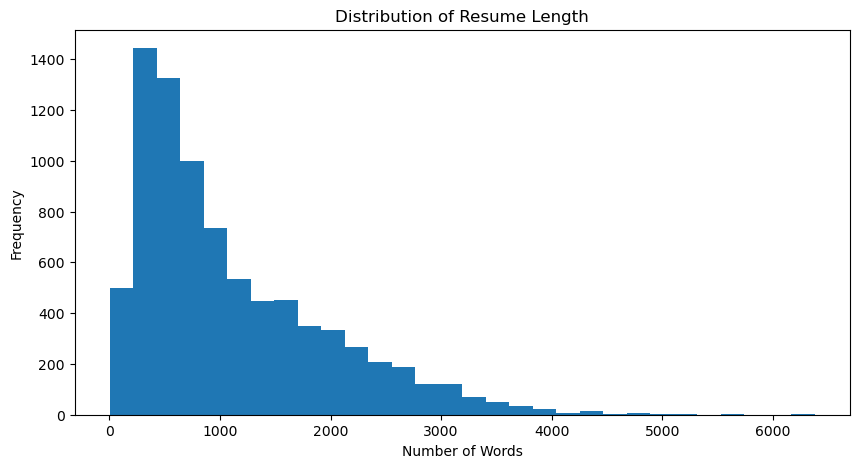

In [24]:
plt.figure(figsize=(10,5))

plt.hist(df["Resume_Length"], bins=30)

plt.title("Distribution of Resume Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

### Section 4: Text Preprocessing (NLP) ###

In [28]:
# Load stopwords
stop_words = set(stopwords.words("english"))

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

In [27]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove phone numbers
    text = re.sub(r'\+?\d[\d\s()-]{8,}\d', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(cleaned_words)

In [29]:
df["Cleaned_Resume"] = df["Resume"].apply(preprocess_text)

In [30]:
print("Original Resume:\n")
print(df["Resume"][0])

print("\n" + "="*80 + "\n")

print("Cleaned Resume:\n")
print(df["Cleaned_Resume"][0])

Original Resume:

Python Developer Python Developer Philadelphia, PA Work Experience Python Developer December 2017 to Present Python Developer 2 Years Education Bachelor's in Computer Science Philadelphia, PA


Cleaned Resume:

python developer python developer philadelphia pa work experience python developer december present python developer year education bachelor computer science philadelphia pa


In [31]:
df.head()

,Resume,Category,Resume_Length,Cleaned_Resume
0,Python Developer Python Developer Philadelphia...,Python_Developer,25,python developer python developer philadelphia...
1,Python Developer Python Developer Python Devel...,Python_Developer,525,python developer python developer python devel...
2,R&D Engineer R&D Engineer R&D Engineer - Nokia...,Python_Developer,408,rd engineer rd engineer rd engineer nokia solu...
3,Sr. Full Stack Developer Sr. Full Stack Develo...,Python_Developer,2325,sr full stack developer sr full stack develope...
4,Sr. Full Stack Python Developer Sr. Full Stack...,Python_Developer,1298,sr full stack python developer sr full stack p...


### Section 5: Feature Engineering (TF-IDF) ###

In [32]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

In [33]:
resume_vectors = tfidf.fit_transform(df["Cleaned_Resume"])

In [34]:
print("TF-IDF Matrix Shape:", resume_vectors.shape)

TF-IDF Matrix Shape: (8234, 5000)


In [35]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:50])

['aa' 'ability' 'ability work' 'able' 'acceptance' 'acceptance testing'
 'access' 'access control' 'access data' 'access database' 'access layer'
 'access management' 'access object' 'access point' 'accessibility'
 'accessing' 'accomplishment' 'accordance' 'according' 'accordingly'
 'account' 'account management' 'accountability' 'accounting'
 'accreditation' 'accuracy' 'accurate' 'accurately' 'achieve' 'achieved'
 'achievement' 'achieving' 'acquisition' 'across' 'across multiple' 'act'
 'acted' 'action' 'action class' 'action milestone' 'active'
 'active directory' 'actively' 'actively involved' 'activity'
 'activity like' 'ad' 'adapt' 'adapter' 'add']


### Section 6: Resume Matching Engine ###

In [36]:
job_description = """
We are looking for a Data Scientist with strong knowledge of Python,
Machine Learning, Deep Learning, SQL, Pandas, NumPy,
Scikit-learn, Data Visualization, Power BI, Statistics,
and Artificial Intelligence.

Candidates should have experience in data analysis,
predictive modeling, feature engineering,
and building machine learning models.
"""

In [37]:
cleaned_jd = preprocess_text(job_description)
print(cleaned_jd)

looking data scientist strong knowledge python machine learning deep learning sql panda numpy scikitlearn data visualization power bi statistic artificial intelligence candidate experience data analysis predictive modeling feature engineering building machine learning model


In [38]:
jd_vector = tfidf.transform([cleaned_jd])

In [39]:
similarity_scores = cosine_similarity(jd_vector, resume_vectors)

In [40]:
df["Match_Score"] = similarity_scores.flatten() * 100

In [41]:
ranked_resumes = df.sort_values(
    by="Match_Score",
    ascending=False
)

In [42]:
ranked_resumes[
    ["Category", "Match_Score"]
].head(10)

,Category,Match_Score
89,Python_Developer,53.327321
503,Python_Developer,52.012678
111,Python_Developer,49.944408
1126,Python_Developer,48.602038
498,Python_Developer,48.469715
1039,Python_Developer,45.515693
932,Python_Developer,45.502587
971,Python_Developer,45.044257
1061,Python_Developer,44.392634
966,Python_Developer,43.613226


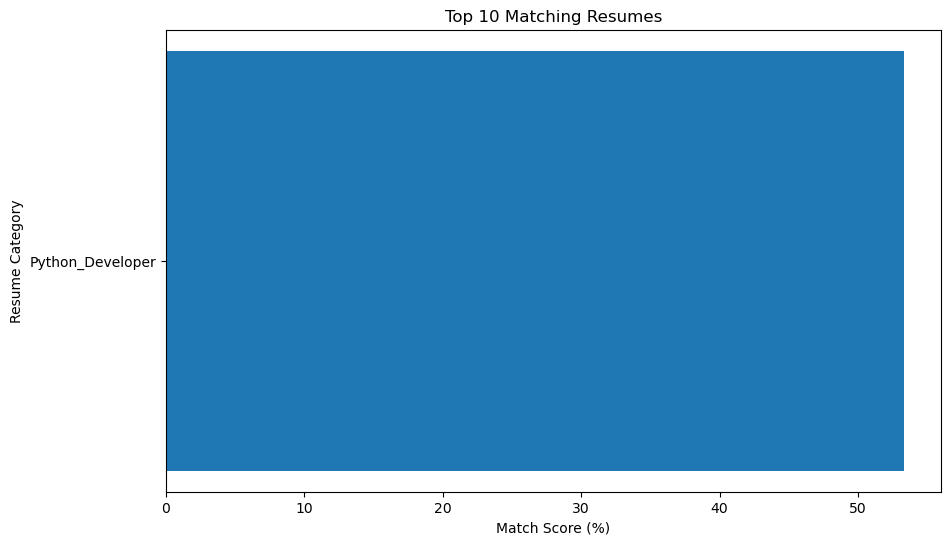

In [43]:
top10 = ranked_resumes.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Category"], top10["Match_Score"])

plt.xlabel("Match Score (%)")
plt.ylabel("Resume Category")
plt.title("Top 10 Matching Resumes")

plt.gca().invert_yaxis()

plt.show()

### Section 7: Recommendation Engine ###

In [44]:
def get_recommendation(score):

    if score >= 85:
        return "⭐ Highly Recommended"

    elif score >= 70:
        return "✅ Recommended"

    elif score >= 50:
        return "⚠ Consider"

    else:
        return "❌ Not Recommended"

In [45]:
df["Recommendation"] = df["Match_Score"].apply(get_recommendation)

In [46]:
df["Resume_ID"] = [
    f"RESUME_{i+1:03d}"
    for i in range(len(df))
]

In [47]:
results = df[
    [
        "Resume_ID",
        "Category",
        "Match_Score",
        "Recommendation"
    ]
]

results.sort_values(
    by="Match_Score",
    ascending=False
).head(10)

,Resume_ID,Category,Match_Score,Recommendation
89,RESUME_090,Python_Developer,53.327321,⚠ Consider
503,RESUME_504,Python_Developer,52.012678,⚠ Consider
111,RESUME_112,Python_Developer,49.944408,❌ Not Recommended
1126,RESUME_1127,Python_Developer,48.602038,❌ Not Recommended
498,RESUME_499,Python_Developer,48.469715,❌ Not Recommended
1039,RESUME_1040,Python_Developer,45.515693,❌ Not Recommended
932,RESUME_933,Python_Developer,45.502587,❌ Not Recommended
971,RESUME_972,Python_Developer,45.044257,❌ Not Recommended
1061,RESUME_1062,Python_Developer,44.392634,❌ Not Recommended
966,RESUME_967,Python_Developer,43.613226,❌ Not Recommended


In [48]:
top_candidate = results.sort_values(
    by="Match_Score",
    ascending=False
).iloc[0]

print("Top Candidate")
print("-" * 40)
print(f"Resume ID      : {top_candidate['Resume_ID']}")
print(f"Category       : {top_candidate['Category']}")
print(f"Match Score    : {top_candidate['Match_Score']:.2f}%")
print(f"Recommendation : {top_candidate['Recommendation']}")

Top Candidate
----------------------------------------
Resume ID      : RESUME_090
Category       : Python_Developer
Match Score    : 53.33%
Recommendation : ⚠ Consider


In [49]:
results.sort_values(
    by="Match_Score",
    ascending=False
).to_csv(
    "../outputs/resume_ranking.csv",
    index=False
)

### Section 8: Skill Extraction Engine ###

In [50]:
SKILLS = {

    # Programming Languages
    "python", "java", "c", "c++", "c#", "javascript", "typescript",

    # Databases
    "sql", "mysql", "postgresql", "mongodb", "oracle",

    # Data Science
    "machine learning", "deep learning", "artificial intelligence",
    "data science", "statistics", "numpy", "pandas",
    "matplotlib", "seaborn", "scikit-learn",

    # AI
    "tensorflow", "keras", "pytorch", "opencv", "nlp",

    # Big Data
    "hadoop", "spark",

    # Cloud
    "aws", "azure", "gcp",

    # DevOps
    "docker", "kubernetes", "jenkins", "git", "github",

    # Visualization
    "power bi", "tableau", "excel",

    # Web Development
    "html", "css", "react", "nodejs", "flask", "django",

    # Others
    "linux", "communication", "problem solving"
}

In [51]:
def extract_skills(text):

    text = text.lower()

    found_skills = set()

    for skill in SKILLS:

        if skill in text:
            found_skills.add(skill)

    return sorted(found_skills)

In [52]:
df["Extracted_Skills"] = df["Cleaned_Resume"].apply(extract_skills)

In [54]:
jd_skills = extract_skills(cleaned_jd)
print(jd_skills)

['artificial intelligence', 'c', 'deep learning', 'machine learning', 'numpy', 'power bi', 'python', 'sql']


In [55]:
print(df["Extracted_Skills"][0])

['c', 'python']


In [56]:
df[
    [
        "Resume_ID",
        "Category",
        "Extracted_Skills"
    ]
].head()

,Resume_ID,Category,Extracted_Skills
0,RESUME_001,Python_Developer,"[c, python]"
1,RESUME_002,Python_Developer,"[aws, c, communication, docker, gcp, git, jenk..."
2,RESUME_003,Python_Developer,"[c, docker, excel, git, java, jenkins, python,..."
3,RESUME_004,Python_Developer,"[aws, c, django, docker, excel, flask, git, gi..."
4,RESUME_005,Python_Developer,"[aws, c, communication, django, docker, excel,..."


In [57]:
from collections import Counter

all_skills = []

for skills in df["Extracted_Skills"]:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)

print(skill_counts.most_common(20))

[('c', 8234), ('sql', 5216), ('java', 4720), ('html', 4565), ('communication', 4214), ('javascript', 4194), ('git', 3955), ('excel', 3777), ('linux', 3512), ('oracle', 3477), ('mysql', 3318), ('python', 2259), ('aws', 2230), ('jenkins', 1901), ('mongodb', 1773), ('github', 1710), ('nodejs', 1696), ('react', 1620), ('css', 1365), ('django', 1212)]


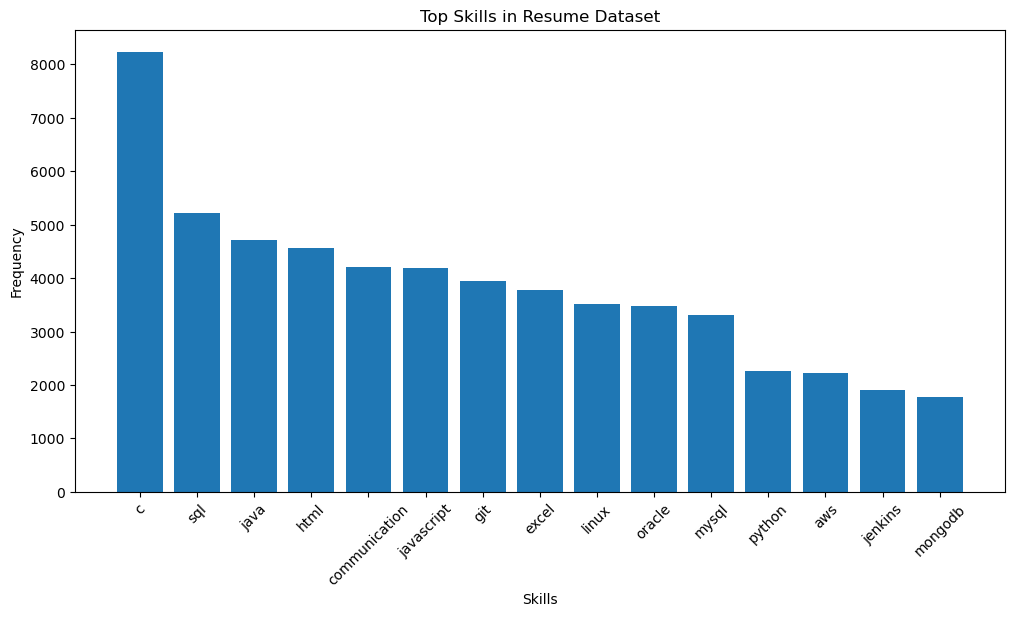

In [58]:
top_skills = skill_counts.most_common(15)

skills = [item[0] for item in top_skills]
counts = [item[1] for item in top_skills]

plt.figure(figsize=(12,6))

plt.bar(skills, counts)

plt.xticks(rotation=45)
plt.title("Top Skills in Resume Dataset")
plt.xlabel("Skills")
plt.ylabel("Frequency")

plt.show()

### Section 9: Skill Gap Analysis ###

In [59]:
def compare_skills(resume_skills, jd_skills):

    matched_skills = sorted(set(resume_skills) & set(jd_skills))

    missing_skills = sorted(set(jd_skills) - set(resume_skills))

    return matched_skills, missing_skills

In [60]:
comparison_results = df["Extracted_Skills"].apply(
    lambda skills: compare_skills(skills, jd_skills)
)

In [61]:
df["Matched_Skills"] = comparison_results.apply(lambda x: x[0])

df["Missing_Skills"] = comparison_results.apply(lambda x: x[1])

In [62]:
df["Skill_Match_Percentage"] = df["Matched_Skills"].apply(

    lambda skills:
    round((len(skills) / len(jd_skills)) * 100, 2)

)

In [63]:
df[
    [
        "Resume_ID",
        "Category",
        "Match_Score",
        "Skill_Match_Percentage"
    ]
].head()

,Resume_ID,Category,Match_Score,Skill_Match_Percentage
0,RESUME_001,Python_Developer,3.923331,25.0
1,RESUME_002,Python_Developer,15.740114,50.0
2,RESUME_003,Python_Developer,2.310120,37.5
3,RESUME_004,Python_Developer,8.703768,62.5
4,RESUME_005,Python_Developer,9.340939,50.0


In [64]:
candidate = df.sort_values(
    by="Match_Score",
    ascending=False
).iloc[0]

print("="*60)

print("Candidate Report")

print("="*60)

print(f"Resume ID           : {candidate['Resume_ID']}")

print(f"Category            : {candidate['Category']}")

print(f"Match Score         : {candidate['Match_Score']:.2f}%")

print(f"Skill Match         : {candidate['Skill_Match_Percentage']}%")

print(f"Recommendation      : {candidate['Recommendation']}")

print("\nMatched Skills")

print("-"*40)

print(", ".join(candidate["Matched_Skills"]))

print("\nMissing Skills")

print("-"*40)

print(", ".join(candidate["Missing_Skills"]))

Candidate Report
Resume ID           : RESUME_090
Category            : Python_Developer
Match Score         : 53.33%
Skill Match         : 75.0%
Recommendation      : ⚠ Consider

Matched Skills
----------------------------------------
c, deep learning, machine learning, numpy, python, sql

Missing Skills
----------------------------------------
artificial intelligence, power bi


In [65]:
final_results = df[
    [
        "Resume_ID",
        "Category",
        "Match_Score",
        "Skill_Match_Percentage",
        "Recommendation"
    ]
]

final_results.sort_values(
    by="Match_Score",
    ascending=False
).head(10)

,Resume_ID,Category,Match_Score,Skill_Match_Percentage,Recommendation
89,RESUME_090,Python_Developer,53.327321,75.0,⚠ Consider
503,RESUME_504,Python_Developer,52.012678,62.5,⚠ Consider
111,RESUME_112,Python_Developer,49.944408,75.0,❌ Not Recommended
1126,RESUME_1127,Python_Developer,48.602038,75.0,❌ Not Recommended
498,RESUME_499,Python_Developer,48.469715,62.5,❌ Not Recommended
1039,RESUME_1040,Python_Developer,45.515693,62.5,❌ Not Recommended
932,RESUME_933,Python_Developer,45.502587,87.5,❌ Not Recommended
971,RESUME_972,Python_Developer,45.044257,87.5,❌ Not Recommended
1061,RESUME_1062,Python_Developer,44.392634,87.5,❌ Not Recommended
966,RESUME_967,Python_Developer,43.613226,87.5,❌ Not Recommended


 ### Section 10: Recruiter Analytics Dashboard ###

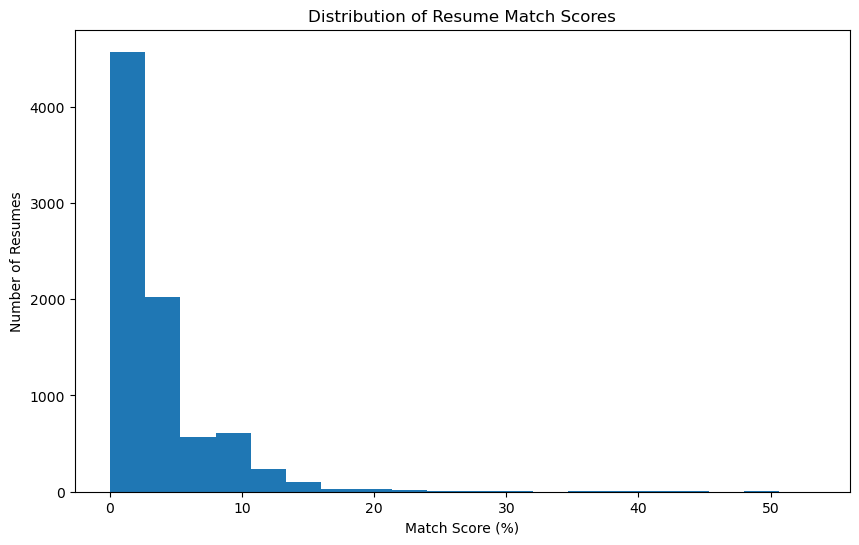

In [66]:
plt.figure(figsize=(10,6))

plt.hist(df["Match_Score"], bins=20)

plt.title("Distribution of Resume Match Scores")

plt.xlabel("Match Score (%)")

plt.ylabel("Number of Resumes")

plt.show()

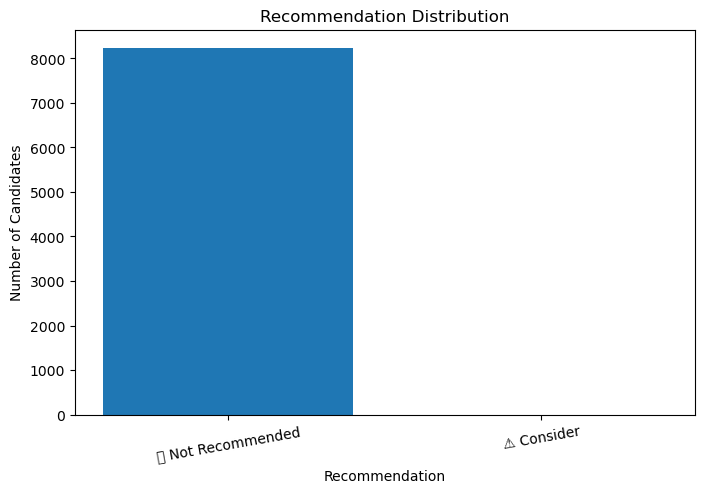

In [67]:
recommendation_counts = df["Recommendation"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(recommendation_counts.index,
        recommendation_counts.values)

plt.title("Recommendation Distribution")

plt.xlabel("Recommendation")

plt.ylabel("Number of Candidates")

plt.xticks(rotation=10)

plt.show()

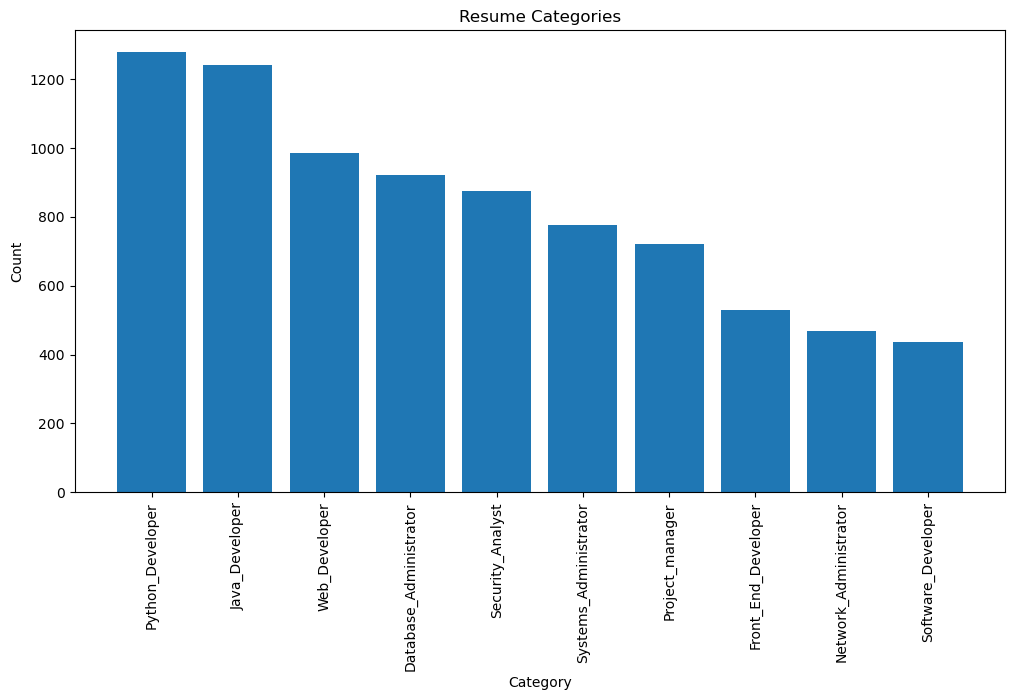

In [68]:
category_counts = df["Category"].value_counts()

plt.figure(figsize=(12,6))

plt.bar(category_counts.index,
        category_counts.values)

plt.xticks(rotation=90)

plt.title("Resume Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

In [70]:
from collections import Counter

missing_skill_counter = Counter()

for skills in df["Missing_Skills"]:
    missing_skill_counter.update(skills)

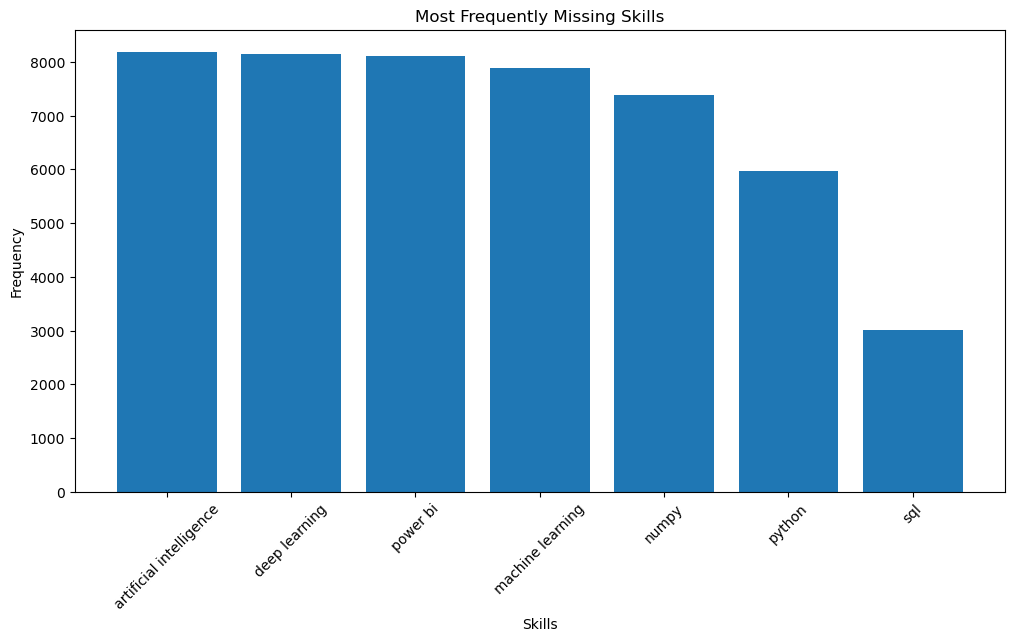

In [71]:
top_missing = missing_skill_counter.most_common(15)

skills = [x[0] for x in top_missing]

counts = [x[1] for x in top_missing]

plt.figure(figsize=(12,6))

plt.bar(skills, counts)

plt.xticks(rotation=45)

plt.title("Most Frequently Missing Skills")

plt.xlabel("Skills")

plt.ylabel("Frequency")

plt.show()

In [72]:
top10 = df.sort_values(
    by="Match_Score",
    ascending=False
).head(10)

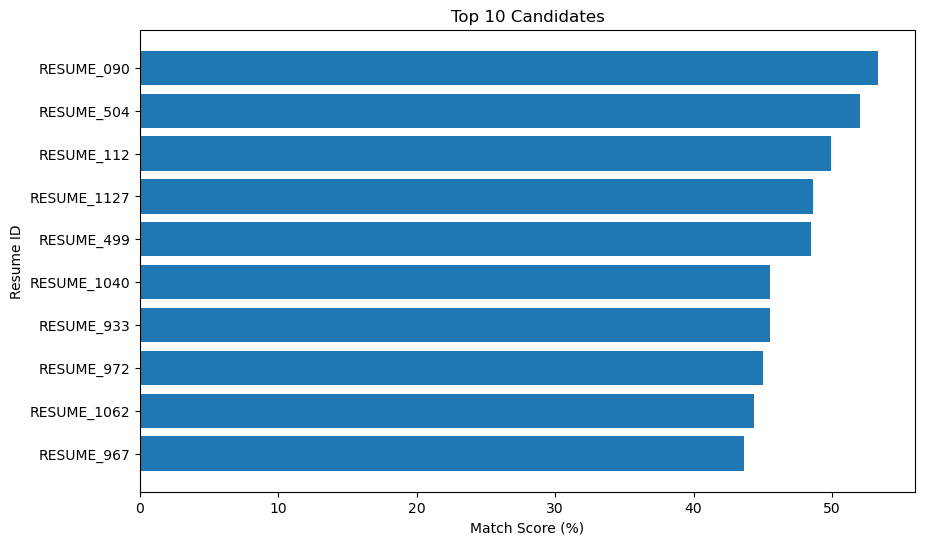

In [73]:
plt.figure(figsize=(10,6))

plt.barh(
    top10["Resume_ID"],
    top10["Match_Score"]
)

plt.xlabel("Match Score (%)")

plt.ylabel("Resume ID")

plt.title("Top 10 Candidates")

plt.gca().invert_yaxis()

plt.show()

In [74]:
dashboard = df[
    [
        "Resume_ID",
        "Category",
        "Match_Score",
        "Skill_Match_Percentage",
        "Recommendation"
    ]
].sort_values(
    by="Match_Score",
    ascending=False
)

dashboard.head(20)

,Resume_ID,Category,Match_Score,Skill_Match_Percentage,Recommendation
89,RESUME_090,Python_Developer,53.327321,75.0,⚠ Consider
503,RESUME_504,Python_Developer,52.012678,62.5,⚠ Consider
111,RESUME_112,Python_Developer,49.944408,75.0,❌ Not Recommended
1126,RESUME_1127,Python_Developer,48.602038,75.0,❌ Not Recommended
498,RESUME_499,Python_Developer,48.469715,62.5,❌ Not Recommended
1039,RESUME_1040,Python_Developer,45.515693,62.5,❌ Not Recommended
932,RESUME_933,Python_Developer,45.502587,87.5,❌ Not Recommended
971,RESUME_972,Python_Developer,45.044257,87.5,❌ Not Recommended
1061,RESUME_1062,Python_Developer,44.392634,87.5,❌ Not Recommended
966,RESUME_967,Python_Developer,43.613226,87.5,❌ Not Recommended
